# Model Quantization and LoRA

Large language models are expensive. A 7 billion parameter model in full precision takes ~28GB of memory just to *load*, let alone train. In this lecture, we'll look at two techniques that make it practical to run and fine-tune large models on consumer hardware:

1. **Quantization**: Reducing the numerical precision of model weights to shrink memory usage
2. **LoRA (Low-Rank Adaptation)**: Fine-tuning a tiny fraction of a model's parameters instead of all of them

Combined, these techniques (often called **QLoRA**) let you fine-tune models that would otherwise be far too large to work with.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## How Big Are These Models, Really?

Let's start by loading a model and seeing how much memory it takes. We'll use Qwen 2.5 1.5B, a relatively small model by today's standards.

In [2]:
model_name = "Qwen/Qwen2.5-1.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_fp32 = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float32)

num_params = sum(p.numel() for p in model_fp32.parameters())
print(f"Parameters: {num_params:,}")
print(f"Dtype: {next(model_fp32.parameters()).dtype}")
print(f"Bytes per parameter: {next(model_fp32.parameters()).element_size()}")
print(f"Total memory: {num_params * next(model_fp32.parameters()).element_size() / 1e9:.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Parameters: 1,543,714,304
Dtype: torch.float32
Bytes per parameter: 4
Total memory: 6.17 GB


That's just to *load* the weights. Training requires even more memory: we need to store gradients (same size as the weights) plus optimizer states (typically 2x the weights for Adam). So fine-tuning a 1.5B parameter model in FP32 could need roughly **4x** the model size in memory, or ~24GB.

Now imagine a 7B model (28GB just for weights), or a 70B model (280GB). This is why quantization matters.

## Number Representation

Before we talk about quantization, we need to understand how numbers are stored in a computer. Every parameter in a neural network is a floating-point number, and the **precision** we use to store it determines both the memory cost and the numerical accuracy.

### Floating-Point Formats

A floating-point number is stored as three components: a **sign bit**, an **exponent**, and a **mantissa** (also called the significand or fraction):

$$\text{value} = (-1)^{\text{sign}} \times 2^{\text{exponent}} \times (1 + \text{mantissa})$$

The more bits we allocate, the more precise the number. Here are the common formats:

| Format | Total Bits | Exponent | Mantissa | Range | Precision |
|--------|-----------|----------|----------|-------|-----------|
| FP32   | 32        | 8        | 23       | ~$\pm 3.4 \times 10^{38}$ | ~7 decimal digits |
| FP16   | 16        | 5        | 10       | ~$\pm 6.5 \times 10^{4}$ | ~3 decimal digits |
| BF16   | 16        | 8        | 7        | ~$\pm 3.4 \times 10^{38}$ | ~2 decimal digits |
| INT8   | 8         | — | — | $-128$ to $127$ | Exact integers only |
| INT4   | 4         | — | — | $-8$ to $7$ | Exact integers only |

BF16 ("brain float") is worth highlighting: it keeps the same exponent range as FP32 (so it can represent the same magnitudes) but sacrifices mantissa precision. This turns out to work very well for neural networks, where the *scale* of values matters more than the last few decimal places.

Let's see this concretely in PyTorch. We can create the same tensor in different precisions and compare their memory usage.

In [3]:
t = torch.randn(1000, 1000)

for dtype, name in [(torch.float32, "FP32"), (torch.float16, "FP16"), (torch.bfloat16, "BF16"), (torch.int8, "INT8")]:
    converted = t.to(dtype)
    bytes_per_element = converted.element_size()
    total_mb = converted.nelement() * bytes_per_element / 1e6
    print(f"{name:5s}: {bytes_per_element} bytes/element, {total_mb:.1f} MB total")

FP32 : 4 bytes/element, 4.0 MB total
FP16 : 2 bytes/element, 2.0 MB total
BF16 : 2 bytes/element, 2.0 MB total
INT8 : 1 bytes/element, 1.0 MB total


Does reducing precision actually hurt? Let's check. We'll do a matrix multiplication in FP32 and FP16 and compare the results.

In [4]:
a = torch.randn(256, 256)
b = torch.randn(256, 256)

result_fp32 = a @ b
result_fp16 = (a.half() @ b.half()).float()

diff = (result_fp32 - result_fp16).abs()
print(f"Max absolute error: {diff.max().item():.6f}")
print(f"Mean absolute error: {diff.mean().item():.6f}")
print(f"Max value in result: {result_fp32.abs().max().item():.2f}")
print(f"Relative error: {(diff / result_fp32.abs().clamp(min=1e-8)).mean().item():.6f}")

Max absolute error: 0.030350
Mean absolute error: 0.004503
Max value in result: 70.57
Relative error: 0.002572


The errors are tiny. In practice, most modern LLMs are trained in BF16 or FP16 from the start, because the precision loss is negligible and you get 2x memory savings for free. But can we go further? Can we use 8 bits, or even 4?

## Quantization

Quantization is the process of mapping floating-point values to a smaller, discrete set of values. The simplest form is **absmax quantization**, which maps floats to 8-bit integers.

### Absmax Quantization (INT8)

The idea is straightforward:

1. Find the maximum absolute value in the tensor: $\alpha = \max(|X|)$
2. Compute a scale factor: $s = \frac{127}{\alpha}$
3. Quantize: $X_q = \text{round}(s \cdot X)$, clamped to $[-128, 127]$

To dequantize (recover an approximation of the original values):

$$\hat{X} = \frac{X_q}{s}$$

Let's implement this by hand.

In [5]:
def quantize_absmax(tensor):
    scale = 127.0 / tensor.abs().max()
    quantized = (tensor * scale).round().clamp(-128, 127).to(torch.int8)
    return quantized, scale

def dequantize(quantized, scale):
    return quantized.float() / scale

# Grab a real weight matrix from our model
weight = model_fp32.model.layers[0].self_attn.q_proj.weight.data.clone()
print(f"Original weight shape: {weight.shape}")
print(f"Original dtype: {weight.dtype}")
print(f"Original memory: {weight.nelement() * weight.element_size() / 1e6:.2f} MB")
print(f"Value range: [{weight.min().item():.4f}, {weight.max().item():.4f}]")
print()

# Quantize
weight_q, scale = quantize_absmax(weight)
print(f"Quantized dtype: {weight_q.dtype}")
print(f"Quantized memory: {weight_q.nelement() * weight_q.element_size() / 1e6:.2f} MB")
print(f"Compression ratio: {weight.element_size() / weight_q.element_size()}x")
print()

# Dequantize and measure error
weight_deq = dequantize(weight_q, scale)
error = (weight - weight_deq).abs()
print(f"Max absolute error: {error.max().item():.6f}")
print(f"Mean absolute error: {error.mean().item():.6f}")

Original weight shape: torch.Size([1536, 1536])
Original dtype: torch.float32
Original memory: 9.44 MB
Value range: [-1.2031, 1.4062]

Quantized dtype: torch.int8
Quantized memory: 2.36 MB
Compression ratio: 4.0x

Max absolute error: 0.005529
Mean absolute error: 0.002769


Let's visualize how quantization affects the distribution of weight values. Because we're mapping a continuous distribution to only 256 discrete buckets (for INT8), we lose some resolution, but the overall shape is preserved.

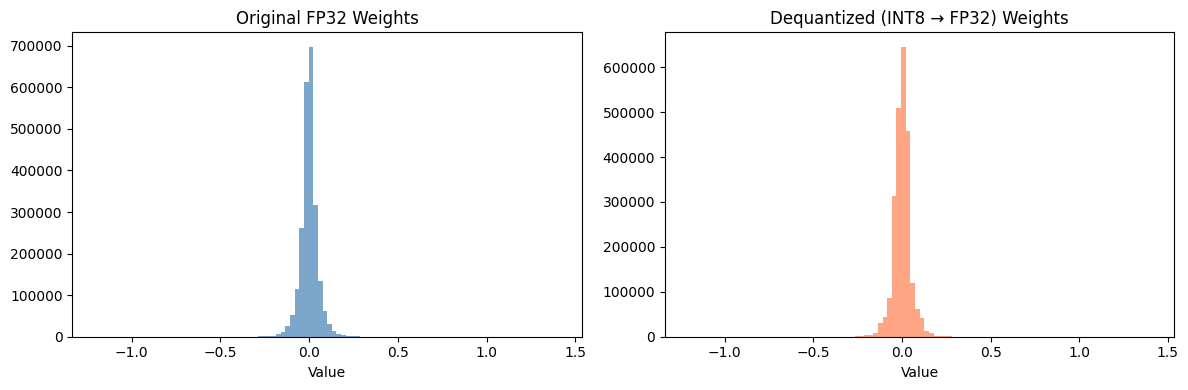

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(weight.flatten().numpy(), bins=100, alpha=0.7, color="steelblue")
axes[0].set_title("Original FP32 Weights")
axes[0].set_xlabel("Value")

axes[1].hist(weight_deq.flatten().numpy(), bins=100, alpha=0.7, color="coral")
axes[1].set_title("Dequantized (INT8 → FP32) Weights")
axes[1].set_xlabel("Value")

plt.tight_layout()
plt.show()

### The Problem with Outliers

Absmax quantization has a weakness: if there's a single outlier value that's much larger than the rest, it dominates the scale factor and wastes most of the integer range on values that don't exist. Neural network weights are typically normally distributed (clustered near zero), so a single outlier at, say, 10x the standard deviation means most of the 256 INT8 buckets represent values no weight actually takes.

Modern quantization methods address this with techniques like **blockwise quantization** (computing separate scale factors for small blocks of weights) and **NormalFloat (NF4)**, which spaces the quantization levels according to a normal distribution rather than uniformly. We won't implement these from scratch, but we'll use them through the `bitsandbytes` library.

## Quantization in Practice

Let's load the same model in 4-bit precision using `bitsandbytes` and compare. The `BitsAndBytesConfig` tells Hugging Face to quantize the model on the fly as it loads.

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                # Use 4-bit quantization
    bnb_4bit_quant_type="nf4",        # NormalFloat4: quantization levels follow a normal distribution
    bnb_4bit_compute_dtype=torch.bfloat16,  # Do computations in BF16 for speed
)

model_4bit = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [8]:
print(f"FP32 model memory: {model_fp32.get_memory_footprint() / 1e9:.2f} GB")
print(f"4-bit model memory: {model_4bit.get_memory_footprint() / 1e9:.2f} GB")
print(f"Compression ratio: {model_fp32.get_memory_footprint() / model_4bit.get_memory_footprint():.1f}x")

FP32 model memory: 6.17 GB
4-bit model memory: 1.12 GB
Compression ratio: 5.5x


### Comparing Output Quality

The real question: does the quantized model still produce good text? Let's compare generations from both models on the same prompts.

In [9]:
def generate(model, prompt, max_new_tokens=100):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


prompts = [
    "The key to a good machine learning model is",
    "Cornell University is located in",
    "In a surprising turn of events,",
]

for prompt in prompts:
    print(f"Prompt: \"{prompt}\"\n")
    print(f"  FP32: {generate(model_fp32, prompt)}\n")
    print(f"  4-bit: {generate(model_4bit, prompt)}\n")
    print("-" * 80)

Prompt: "The key to a good machine learning model is"

  FP32: The key to a good machine learning model is not to get the training data set right, but to get the test data right. Test data is a set of data that is used to check the performance of a machine learning algorithm. It is used to evaluate the accuracy of the model and to ensure that it is not overfitting the training data.
There are two main types of test data: cross-validation and holdout. Cross-validation is a technique where the data is divided into k equal-sized subsets, and k models are trained and tested on

  4-bit: The key to a good machine learning model is training it properly. It is not enough to train a model; it is important to train it in a proper way.
Training a machine learning model is not a one-time job. It is a continuous process. It means that training is a part of the machine learning process. The following are the three steps involved in training a machine learning model:
1. Training a model
2. Evaluatin

Try some prompts of your own. Can you find cases where the 4-bit model noticeably diverges from the FP32 model? Keep in mind that both models are sampling, so some variation is expected even between two runs of the same model.

We can free the FP32 model now -- we won't need it anymore, and we need the memory.

In [10]:
del model_fp32
torch.cuda.empty_cache()

## The Fine-Tuning Problem

In Lecture 7, we fine-tuned GPT-2 (124M parameters) on tweets. That was feasible because GPT-2 is small. But what if we want to fine-tune the 1.5B parameter model we just loaded? Or a 7B one?

The memory cost of full fine-tuning is roughly:

| Component | Memory |
|-----------|--------|
| Model weights | $N \times b$ |
| Gradients | $N \times b$ |
| Optimizer states (Adam) | $N \times 2b$ |
| **Total** | **$N \times 4b$** |

where $N$ is the number of parameters and $b$ is bytes per parameter. For our 1.5B model in FP32, that's about $1.5\text{B} \times 16 = 24\text{GB}$ just for the training state, not counting activations.

What if we could fine-tune **less than 1%** of the parameters, while keeping the rest of the model frozen?

## LoRA: Low-Rank Adaptation

### The Intuition

When we fine-tune a model, we update its weight matrices. But research has shown that the *change* in weights during fine-tuning ($\Delta W$) tends to have **low rank**. In other words, the update can be well-approximated by a much smaller matrix.

What does "low rank" mean? A matrix has rank $r$ if it can be expressed as the product of two smaller matrices. For example, if $W$ is a $d \times d$ matrix, a rank-$r$ approximation is:

$$\Delta W = BA$$

where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times d}$, with $r \ll d$.

### The Math

In standard fine-tuning, we update a pretrained weight matrix $W_0$ to get:

$$W = W_0 + \Delta W$$

In LoRA, we instead parameterize the update as:

$$W = W_0 + \frac{\alpha}{r} BA$$

where:
- $W_0 \in \mathbb{R}^{d \times d}$ is the **frozen** pretrained weight (no gradients)
- $B \in \mathbb{R}^{d \times r}$ is a small learnable matrix (initialized to zeros)
- $A \in \mathbb{R}^{r \times d}$ is a small learnable matrix (initialized randomly)
- $r$ is the **rank** (a hyperparameter, typically 8-64)
- $\alpha$ is a scaling factor that controls the magnitude of the update

Since $B$ starts at zero, the model begins at the exact pretrained weights and gradually learns a low-rank adaptation.

### The Parameter Savings

For a weight matrix of shape $d \times d$:
- **Full fine-tuning**: $d^2$ trainable parameters
- **LoRA with rank $r$**: $2 \times d \times r$ trainable parameters

The ratio is $\frac{2r}{d}$. For $d = 2048$ and $r = 16$, that's $\frac{32}{2048} \approx 1.6\%$ of the parameters.

The forward pass computes:

$$h = W_0 x + \frac{\alpha}{r} B A x$$

The input $x$ flows through both paths: the frozen pretrained weight $W_0$ and the trainable low-rank bottleneck $A \rightarrow B$. Notice how $A$ compresses the input from dimension $d$ down to $r$, and then $B$ projects it back up to $d$. This bottleneck is what forces the adaptation to be low-rank.

### Implementing LoRA from Scratch

Let's build a simple LoRA layer to make this concrete.

In [11]:
class LoRALinear(nn.Module):
    def __init__(self, original_layer, r=8, alpha=16):
        super().__init__()
        self.original = original_layer
        self.r = r
        self.alpha = alpha
        
        d_out, d_in = original_layer.weight.shape
        
        # Freeze the original weights
        self.original.weight.requires_grad = False
        if self.original.bias is not None:
            self.original.bias.requires_grad = False
        
        # LoRA matrices
        self.A = nn.Parameter(torch.randn(r, d_in) * 0.01)   # Small random init
        self.B = nn.Parameter(torch.zeros(d_out, r))           # Zero init
    
    def forward(self, x):
        frozen_out = self.original(x)                          # W0 @ x
        lora_out = (x @ self.A.T) @ self.B.T                  # (B @ A) @ x
        return frozen_out + (self.alpha / self.r) * lora_out

In [12]:
# Demonstrate the parameter savings
d = 2048
r = 16

original = nn.Linear(d, d)
lora = LoRALinear(original, r=r)

full_params = sum(p.numel() for p in original.parameters())
lora_trainable = sum(p.numel() for p in lora.parameters() if p.requires_grad)
lora_total = sum(p.numel() for p in lora.parameters())

print(f"Full layer: {full_params:,} parameters")
print(f"LoRA trainable: {lora_trainable:,} parameters ({100*lora_trainable/full_params:.1f}% of full)")
print(f"LoRA total (including frozen): {lora_total:,} parameters")

# Verify it produces the same output initially (since B is zeros)
x = torch.randn(1, 10, d)
with torch.no_grad():
    original_out = original(x)
    lora_out = lora(x)
print(f"\nOutputs match at initialization: {torch.allclose(original_out, lora_out, atol=1e-6)}")

Full layer: 4,196,352 parameters
LoRA trainable: 65,536 parameters (1.6% of full)
LoRA total (including frozen): 4,261,888 parameters

Outputs match at initialization: True


The key thing to note: at initialization, the LoRA layer produces the **exact same output** as the original layer, because $B$ is all zeros. Training will gradually learn a low-rank adjustment.

### Where Do We Apply LoRA?

In a transformer, the attention mechanism has four weight matrices: $W_Q$, $W_K$, $W_V$, and $W_O$ (the output projection). The MLP blocks have additional weight matrices. LoRA is typically applied to the attention projection matrices, most commonly $W_Q$ and $W_V$. You can apply it to more layers for greater capacity at the cost of more trainable parameters.

## Applying LoRA with PEFT

In practice, we don't need to implement LoRA ourselves. Hugging Face's `peft` (Parameter-Efficient Fine-Tuning) library handles it for us. Let's apply LoRA to our 4-bit quantized model -- this combination is known as **QLoRA**.

In [13]:
lora_config = LoraConfig(
    r=32,                                        # Rank of the low-rank matrices
    lora_alpha=32,                               # Scaling factor (alpha/r applied to LoRA output)
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
     ],                                          # Which layers to apply LoRA to
    bias="none",                                 # Don't train biases
    task_type=TaskType.CAUSAL_LM,                # We're doing causal language modeling
)

peft_model = get_peft_model(model_4bit, lora_config)
peft_model.print_trainable_parameters()

trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364


About 1% of the model's parameters are trainable. The rest are frozen and quantized to 4 bits. Let's take a look at what the model looks like with LoRA applied.

In [14]:
# Look at one transformer layer to see the LoRA adapters
print(peft_model.model.model.layers[0].self_attn)

Qwen2Attention(
  (q_proj): lora.Linear4bit(
    (base_layer): Linear4bit(in_features=1536, out_features=1536, bias=True)
    (lora_dropout): ModuleDict(
      (default): Identity()
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=1536, out_features=32, bias=False)
    )
    (lora_B): ModuleDict(
      (default): Linear(in_features=32, out_features=1536, bias=False)
    )
    (lora_embedding_A): ParameterDict()
    (lora_embedding_B): ParameterDict()
    (lora_magnitude_vector): ModuleDict()
  )
  (k_proj): lora.Linear4bit(
    (base_layer): Linear4bit(in_features=1536, out_features=256, bias=True)
    (lora_dropout): ModuleDict(
      (default): Identity()
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=1536, out_features=32, bias=False)
    )
    (lora_B): ModuleDict(
      (default): Linear(in_features=32, out_features=256, bias=False)
    )
    (lora_embedding_A): ParameterDict()
    (lora_embedding_B): ParameterDict()
    (lora_magnitude_vect

## QLoRA Fine-Tuning

Now let's put it all together and fine-tune our quantized model with LoRA. We'll reuse the tweet dataset from Lecture 7: we'll train on positive tweets (joy and optimism) to shift the model's style. This is a simple domain shift that trains quickly and produces visible results.

In [ ]:
from datasets import load_dataset
from transformers import DataCollatorForLanguageModeling, TrainingArguments, Trainer

# Load the same tweet dataset from Lecture 7
# Labels: 0=anger, 1=joy, 2=optimism, 3=sadness
tweet_dataset = load_dataset('cardiffnlp/tweet_eval', 'emotion', split='train')

# Keep only positive tweets (joy + optimism)
tweet_dataset = tweet_dataset.filter(lambda x: x['label'] in [1, 2])
print(f'Positive tweets: {len(tweet_dataset)}')
print(f'Example: {tweet_dataset[0]["text"]}')

Since we're doing causal language modeling (not instruction following), we just need to tokenize the tweets as plain text. The model will learn to generate text that looks like positive tweets.

In [ ]:
block_size = 64
tokenizer.pad_token = tokenizer.eos_token

def tokenize_fn(batch):
    return tokenizer(
        [text + tokenizer.eos_token for text in batch['text']],
        padding=True,
        truncation=True,
        max_length=block_size,
    )

tokenized = tweet_dataset.map(tokenize_fn, batched=True, remove_columns=tweet_dataset.column_names)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

In [ ]:
training_args = TrainingArguments(
    per_device_train_batch_size=16,
    num_train_epochs=1,
    learning_rate=5e-5,
    warmup_steps=15,
    logging_steps=25,
    save_strategy='no',
    report_to='none',
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=data_collator,
)

trainer.train()

### Trying It Out

Let's see how the model generates after QLoRA fine-tuning on positive tweets. We'll use the same tweet-style prompts from Lecture 7.

In [ ]:
sample_prompts = [
    "Just found out that",
    "The best part about",
    "I can't believe",
    "Hot take:",
    "Honestly I think",
    "I'm convinced that",
    "Not gonna lie",
    "The older I get the more",
]

peft_model.eval()
for prompt_text in sample_prompts:
    inputs = tokenizer(prompt_text, return_tensors="pt").to(peft_model.device)
    with torch.no_grad():
        ids = peft_model.generate(
            **inputs,
            do_sample=True,
            max_new_tokens=64,
            temperature=0.75,
            pad_token_id=tokenizer.eos_token_id,
        )
    print(f'Prompt: "{prompt_text}"')
    print(f"  {tokenizer.decode(ids[0], skip_special_tokens=True)}")
    print()

### Saving and Loading Adapters

One of the most practical advantages of LoRA: you only need to save the tiny adapter weights, not the entire model. The adapter is typically just a few megabytes, compared to gigabytes for the full model.

In [19]:
import os

peft_model.save_pretrained("qwen-lora-adapter")

adapter_size = sum(
    os.path.getsize(os.path.join("qwen-lora-adapter", f))
    for f in os.listdir("qwen-lora-adapter")
    if os.path.isfile(os.path.join("qwen-lora-adapter", f))
)
print(f"Adapter size on disk: {adapter_size / 1e6:.1f} MB")
print(f"\nSaved files:")
for f in sorted(os.listdir("qwen-lora-adapter")):
    print(f"  {f}")

Adapter size on disk: 73.9 MB

Saved files:
  README.md
  adapter_config.json
  adapter_model.safetensors


This is powerful. You can share a ~10MB adapter file and anyone with access to the base model can reproduce your fine-tuned model. You can also train multiple adapters for different tasks and swap between them on the same base model.

## Recap

| Technique | What it does | Memory savings |
|-----------|-------------|----------------|
| **FP16/BF16** | Use 16-bit instead of 32-bit floats | 2x |
| **INT8 quantization** | Map weights to 8-bit integers | 4x |
| **4-bit quantization (NF4)** | Map weights to 4-bit normal floats | 8x |
| **LoRA** | Train low-rank adapters instead of full weights | ~100x fewer trainable params |
| **QLoRA** | Quantize model + LoRA adapters | Both benefits combined |

These techniques are what make it possible to fine-tune billion-parameter models on a single consumer GPU. The base model is quantized to minimize memory, LoRA adds a tiny set of trainable parameters, and the result is a fine-tuned model that would have been impossible to train otherwise.

### Further reading
- [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685) (Hu et al., 2021)
- [QLoRA: Efficient Finetuning of Quantized LLMs](https://arxiv.org/abs/2305.14314) (Dettmers et al., 2023)
- [LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale](https://arxiv.org/abs/2208.07339) (Dettmers et al., 2022)